In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path
from tqdm import tqdm
from config import TrainConfig
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.nn.functional as F


class RWF2000Skeletons(Dataset):
    def __init__(
        self,
        root: str | Path,
        split: str = "train",
        key: str = "skeletons",
        channels: tuple[int, ...] | None = None,  # None → use all channels
    ):
        self.root = Path(root)
        self.split = split
        self.key = key
        self.channels = channels

        split_dir = self.root / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Missing split directory: {split_dir}")

        self.samples: list[tuple[Path, int, int]] = []
        for label_name, label in [("Fight", 1), ("NonFight", 0)]:
            label_dir = split_dir / label_name
            if not label_dir.exists():
                continue
            for npz_path in sorted(label_dir.glob("*.npz")):
                with np.load(npz_path) as data:
                    n = data[self.key].shape[0]
                for idx in range(n):
                    self.samples.append((npz_path, label, idx))
        if not self.samples:
            raise RuntimeError(f"No skeleton files found under {split_dir}")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        npz_path, label, window_idx = self.samples[index]
        with np.load(npz_path) as data:
            window = data[self.key][window_idx]  # (T, V, C_full)
            label_arr = data.get("labels")
            if label_arr is not None:
                label = int(label_arr[window_idx])

        if self.channels is None:
            window_sel = window
        else:
            window_sel = window[..., list(self.channels)]

        window_sel = np.transpose(window_sel, (2, 0, 1)).astype(np.float32)  # (C, T, V)
        return torch.from_numpy(window_sel), torch.tensor(label, dtype=torch.long)


In [2]:
def build_coco_adjacency(num_joints: int = 17):
    # Edge list (COCO keypoint order: 0-nose,1-eyeL,2-eyeR,3-earL,4-earR,5-shoulderL,6-shoulderR,
    # 7-elbowL,8-elbowR,9-wristL,10-wristR,11-hipL,12-hipR,13-kneeL,14-kneeR,15-ankleL,16-ankleR)
    edges = [
        (0, 1), (0, 2), (1, 3), (2, 4),
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
        (11, 12), (5, 11), (6, 12),
        (11, 13), (13, 15), (12, 14), (14, 16)
    ]
    A = torch.eye(num_joints)
    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1
    # Normalize
    D = torch.diag(1.0 / torch.clamp(A.sum(dim=1), min=1.0))
    return D @ A


class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, dropout=0.0):
        super().__init__()
        self.A = nn.Parameter(A, requires_grad=False)  # static adjacency, can make learnable
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(9, 1), stride=(stride, 1), padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        if not residual:
            self.residual = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        # x: (B, C, T, V)
        res = self.residual(x)
        x = torch.einsum("nctv,vw->nctw", x, self.A)  # spatial graph conv (message passing)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.drop(x)
        return x + res


class STGCN(nn.Module):
    def __init__(self, num_classes=2, in_channels=2, graph_nodes=17, base_channels=64, dropout=0.5):
        super().__init__()
        A = build_coco_adjacency(graph_nodes)
        self.register_buffer("A", A)

        channels = [base_channels, base_channels, base_channels, 2*base_channels, 2*base_channels, 4*base_channels]
        strides = [1, 1, 1, 2, 1, 2]  # temporal downsampling
        layers = []
        c_in = in_channels
        for c_out, s in zip(channels, strides):
            layers.append(GraphConv(c_in, c_out, self.A, stride=s, residual=True, dropout=dropout))
            c_in = c_out
        self.stgcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        # x: (B, C, T, V)
        x = self.stgcn(x)
        x = self.pool(x)              # (B, C_out, 1, 1)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [3]:
cfg = TrainConfig()
cfg.batch_size = 64
cfg.max_epochs = 10
train_ds = RWF2000Skeletons("precomputed_skeletons", split="train")
val_ds = RWF2000Skeletons("precomputed_skeletons", split="val")

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.workers)

X_probe, _ = next(iter(train_loader))
Fdim = X_probe.shape[-1]

model_device = 'mps'

In [4]:
base_channels = 64  # try 32/64/96/etc.

model = STGCN(
    num_classes=cfg.num_classes,
    in_channels=7,
    graph_nodes=17,
    base_channels=base_channels,
    dropout=cfg.dropout,
).to(model_device)


In [5]:
import os
save_path = "checkpoints/best_model_2.pth"
criterion = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr)

ckpt_dir = os.path.dirname(save_path)
if ckpt_dir:
    os.makedirs(ckpt_dir, exist_ok=True)

In [6]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils import clip_grad_norm_

cfg.lr = 5e-4
cfg.weight_decay = 1e-4
cfg.dropout = 0.5
cfg.joint_dropout = 0.1
max_epochs = cfg.max_epochs

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = CosineAnnealingLR(optim, T_max=max_epochs)

train_losses, train_accs, train_f1s, train_aucs = [], [], [], []
val_losses, val_accs, val_f1s, val_aucs = [], [], [], []
best_acc = 0.0
best_cm = None  # (labels, preds)

for epoch in range(max_epochs):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}")
    for X, y in pbar:
        X = X.to(model_device)
        y = y.to(model_device)

        if cfg.joint_dropout > 0:
            mask = (torch.rand_like(X[:, :1]) > cfg.joint_dropout).float()
            X = X * mask

        logits = model(X)
        loss = criterion(logits, y)

        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()

        bs = y.size(0)
        preds = logits.argmax(dim=1)
        probs = logits.softmax(dim=1)[:, 1]

        loss_sum += float(loss.item()) * bs
        total += bs
        correct += int((preds == y).sum().item())
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
        all_probs.append(probs.detach().cpu())
        pbar.set_postfix(loss=loss_sum / max(1, total), acc=correct / max(1, total))

    train_loss = loss_sum / max(1, total)
    train_acc = correct / max(1, total)
    train_preds = torch.cat(all_preds).numpy()
    train_labels = torch.cat(all_labels).numpy()
    train_probs = torch.cat(all_probs).numpy()
    train_f1 = f1_score(train_labels, train_preds)
    train_auc = roc_auc_score(train_labels, train_probs)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    train_aucs.append(train_auc)
    scheduler.step()

    model.eval()
    v_total, v_correct, v_loss_sum = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(model_device)
            y = y.to(model_device)
            logits = model(X)
            loss = criterion(logits, y)

            bs = y.size(0)
            preds = logits.argmax(dim=1)
            probs = logits.softmax(dim=1)[:, 1]

            v_loss_sum += float(loss.item()) * bs
            v_total += bs
            v_correct += int((preds == y).sum().item())
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())

    v_loss = v_loss_sum / max(1, v_total)
    v_acc = v_correct / max(1, v_total)
    val_preds = torch.cat(all_preds).numpy()
    val_labels = torch.cat(all_labels).numpy()
    val_probs = torch.cat(all_probs).numpy()
    v_f1 = f1_score(val_labels, val_preds)
    v_auc = roc_auc_score(val_labels, val_probs)
    val_losses.append(v_loss); val_accs.append(v_acc)
    val_f1s.append(v_f1); val_aucs.append(v_auc)

    print(f"Val loss: {v_loss:.4f} | Val acc: {v_acc:.4f} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")

    if v_acc > best_acc:
        best_acc = v_acc
        best_cm = (val_labels.copy(), val_preds.copy())
        torch.save({
            "model": model.state_dict(),
            "num_classes": cfg.num_classes,
            "in_channels": 7,
            "base_channels": base_channels,
            "dropout": cfg.dropout,
        }, save_path)
        print(f"Saved checkpoint to {save_path}")

print("Best val acc:", best_acc)


Epoch 1/10: 100%|██████████| 225/225 [00:26<00:00,  8.38it/s, acc=0.69, loss=0.609] 


Val loss: 0.6188 | Val acc: 0.7044 | Val F1: 0.7087 | Val AUC: 0.7667
Saved checkpoint to checkpoints/best_model_2.pth


Epoch 2/10: 100%|██████████| 225/225 [00:46<00:00,  4.85it/s, acc=0.705, loss=0.586]


Val loss: 0.5930 | Val acc: 0.7050 | Val F1: 0.7145 | Val AUC: 0.7724
Saved checkpoint to checkpoints/best_model_2.pth


Epoch 3/10: 100%|██████████| 225/225 [00:49<00:00,  4.57it/s, acc=0.712, loss=0.584]


...

Val loss: 0.6056 | Val acc: 0.7117 | Val F1: 0.7003 | Val AUC: 0.7713
Saved checkpoint to checkpoints/best_model_2.pth


Epoch 9/10: 100%|██████████| 225/225 [02:34<00:00,  1.46it/s, acc=0.74, loss=0.549]  


Val loss: 0.6336 | Val acc: 0.6814 | Val F1: 0.6231 | Val AUC: 0.7520


Epoch 10/10: 100%|██████████| 225/225 [01:21<00:00,  2.75it/s, acc=0.741, loss=0.545]


Val loss: 0.6296 | Val acc: 0.6856 | Val F1: 0.6322 | Val AUC: 0.7587
Best val acc: 0.7116666666666667


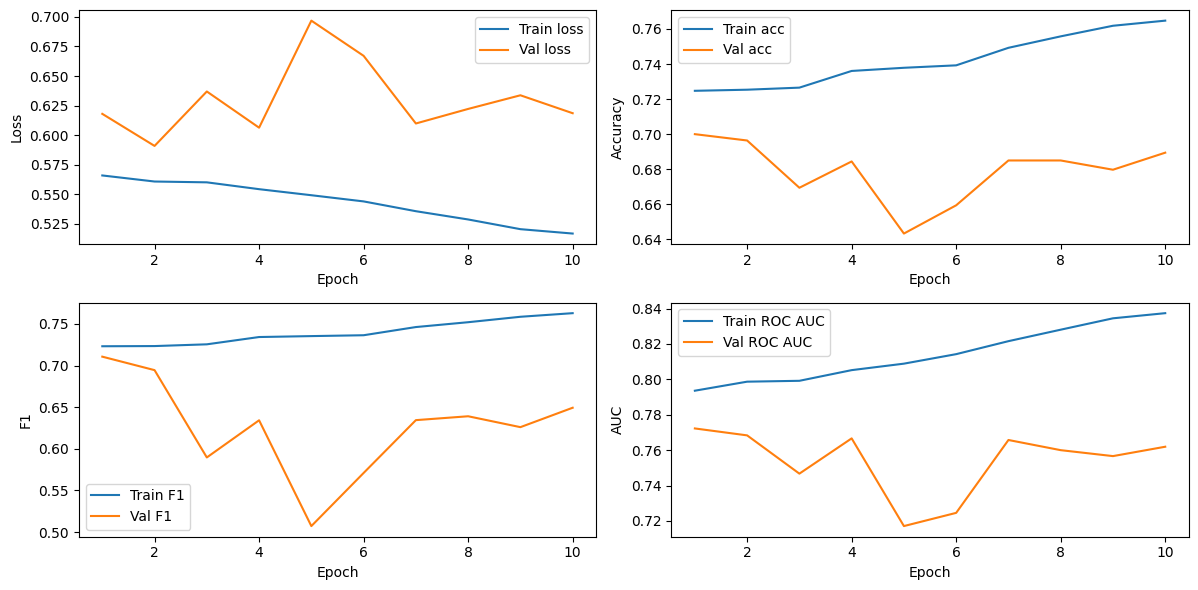

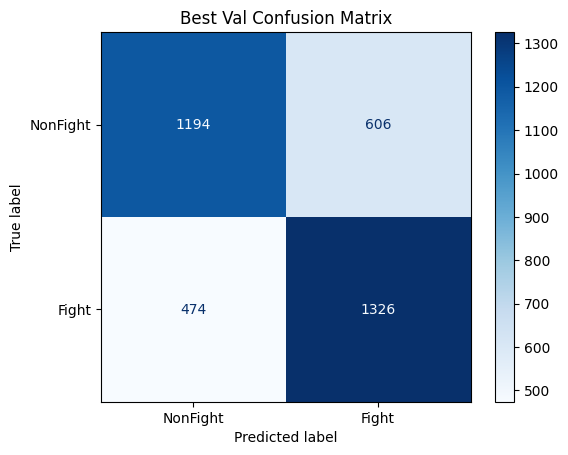

In [9]:
# Plot curves (loss/acc + F1/AUC)
epochs = range(1, max_epochs + 1)
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs, label="Val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.subplot(2, 2, 3)
plt.plot(epochs, train_f1s, label="Train F1")
plt.plot(epochs, val_f1s, label="Val F1")
plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend()
plt.subplot(2, 2, 4)
plt.plot(epochs, train_aucs, label="Train ROC AUC")
plt.plot(epochs, val_aucs, label="Val ROC AUC")
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix for the best checkpoint
if best_cm is not None:
    cm = confusion_matrix(*best_cm)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NonFight", "Fight"])
    disp.plot(cmap="Blues"); plt.title("Best Val Confusion Matrix"); plt.show()

In [6]:
from sklearn.metrics import f1_score, roc_auc_score
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils import clip_grad_norm_

cfg.lr = 5e-4
cfg.weight_decay = 1e-4
cfg.dropout = 0.5
cfg.joint_dropout = 0.1  
max_epochs = cfg.max_epochs

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = CosineAnnealingLR(optim, T_max=max_epochs)

train_losses, train_accs, train_f1s, train_aucs = [], [], [], []
val_losses, val_accs, val_f1s, val_aucs = [], [], [], []
best_acc = 0.0

for epoch in range(max_epochs):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}")
    for X, y in pbar:
        X = X.to(model_device)
        y = y.to(model_device)

        if cfg.joint_dropout > 0:
            mask = (torch.rand_like(X[:, :1]) > cfg.joint_dropout).float()
            X = X * mask

        logits = model(X)
        loss = criterion(logits, y)

        optim.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()

        bs = y.size(0)
        preds = logits.argmax(dim=1)
        probs = logits.softmax(dim=1)[:, 1]

        loss_sum += float(loss.item()) * bs
        total += bs
        correct += int((preds == y).sum().item())
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
        all_probs.append(probs.detach().cpu())
        pbar.set_postfix(loss=loss_sum / max(1, total), acc=correct / max(1, total))

    train_loss = loss_sum / max(1, total)
    train_acc = correct / max(1, total)
    train_preds = torch.cat(all_preds).numpy()
    train_labels = torch.cat(all_labels).numpy()
    train_probs = torch.cat(all_probs).numpy()
    train_f1 = f1_score(train_labels, train_preds)
    train_auc = roc_auc_score(train_labels, train_probs)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    train_aucs.append(train_auc)
    scheduler.step()

    model.eval()
    v_total, v_correct, v_loss_sum = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(model_device)
            y = y.to(model_device)
            logits = model(X)
            loss = criterion(logits, y)

            bs = y.size(0)
            preds = logits.argmax(dim=1)
            probs = logits.softmax(dim=1)[:, 1]

            v_loss_sum += float(loss.item()) * bs
            v_total += bs
            v_correct += int((preds == y).sum().item())
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())

    v_loss = v_loss_sum / max(1, v_total)
    v_acc = v_correct / max(1, v_total)
    val_preds = torch.cat(all_preds).numpy()
    val_labels = torch.cat(all_labels).numpy()
    val_probs = torch.cat(all_probs).numpy()
    v_f1 = f1_score(val_labels, val_preds)
    v_auc = roc_auc_score(val_labels, val_probs)
    val_losses.append(v_loss)
    val_accs.append(v_acc)
    val_f1s.append(v_f1)
    val_aucs.append(v_auc)

    print(f"Val loss: {v_loss:.4f} | Val acc: {v_acc:.4f} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save({
            "model": model.state_dict(),
            "num_classes": cfg.num_classes,
            "in_channels": 7,
            "base_channels": base_channels,
            "dropout": cfg.dropout,
        }, save_path)
        print(f"Saved checkpoint to {save_path}")

print("Best val acc:", best_acc)


Epoch 1/10: 100%|██████████| 225/225 [00:26<00:00,  8.63it/s, acc=0.688, loss=0.611]


Val loss: 0.6091 | Val acc: 0.6889 | Val F1: 0.6767 | Val AUC: 0.7509
Saved checkpoint to checkpoints/best_model.pth


Epoch 2/10: 100%|██████████| 225/225 [00:48<00:00,  4.65it/s, acc=0.705, loss=0.591]


Val loss: 0.6108 | Val acc: 0.7017 | Val F1: 0.7274 | Val AUC: 0.7737
Saved checkpoint to checkpoints/best_model.pth


Epoch 3/10: 100%|██████████| 225/225 [00:35<00:00,  6.38it/s, acc=0.712, loss=0.583]


...

Val loss: 0.6596 | Val acc: 0.6578 | Val F1: 0.5719 | Val AUC: 0.7297


Epoch 9/10: 100%|██████████| 225/225 [00:45<00:00,  4.90it/s, acc=0.741, loss=0.548]


Val loss: 0.6203 | Val acc: 0.6911 | Val F1: 0.6440 | Val AUC: 0.7623


Epoch 10/10: 100%|██████████| 225/225 [00:46<00:00,  4.83it/s, acc=0.742, loss=0.544]


Val loss: 0.6210 | Val acc: 0.6911 | Val F1: 0.6463 | Val AUC: 0.7600
Best val acc: 0.7111111111111111


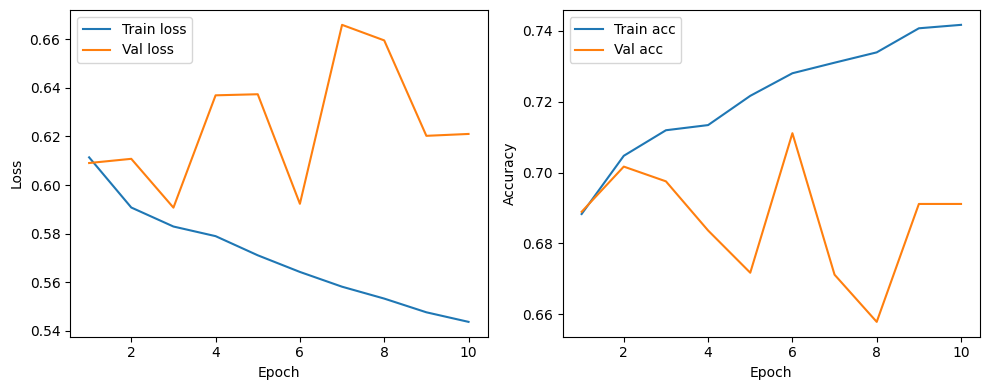

In [7]:
import matplotlib.pyplot as plt
epochs = range(1, max_epochs + 1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs, label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()